#Введение


---
## Знакомство с рабочей средой

Python — основной языкы программирования для работы с моделями машинного обучения и анализа данных. Код в Python хранится в отдельных скриптах, которые пользователь может использовать и писать сам.

Тетради Jupyter notebook позволяют представить весь процесс работы наглядно, а также дополнить код текстами, математическими уравнениями и различными медиа-файлами.  

Мы будем работать с Google Colaboratory - онлайн версией Jupyter Notebook от Google. Сервис Google Colaboratory предоставляет всё необходимое для машинного обучения прямо в браузере и даёт доступ к GPU и TPU (графический процессор и тензорный процессор), что позволяет быстро производить сложные вычисления.

<img src="http://texno.info/wp-content/uploads/2019/09/gc.png" alt="Drawing" style="width: 50px;" width="480"/>

In [ ]:
print(1)

1


# Предсказание дефолта по кредитной карте

Люди берут кредит в банке по разным причинам: кто-то готовится к крупным покупкам, кому-то нужна вещь прямо здесь и сейчас, а кто-то просто не хочет стеснять себя в желаниях. В отличие от кредита наличными, кредитная карта имеет ряд преимуществ, таких как возобновляемость лимита, гибкий график погашения и возможность не платить проценты.  

Увы, хороших заемщиков на всех не хватает. Если клиент не в состоянии погасить свою задолженность в сроки, установленные условиями пользования картой, банк считает, что произошел дефолт.

<img src="https://i1.wp.com/blog.bankbazaar.com/wp-content/uploads/2016/03/Surviving-a-Credit-Card-Default.png?w=1000&ssl=1" alt="Drawing" style="width: 50px;" width="480"/>



**В этой тетради мы**

* рассмотрим классическую задачу машинного обучения - предсказание дефолта;
* познакомимся с основными библиотеками для работы с данными: Pandas, Matplotlib и Scikit-learn;
* исследуем, как извлекать различные статистики из данных и анализировать их визуально;
* обучим модели логистической регрессии и решающих деревьев;
* рассмотрим вопрос измерения качества работы обученных
классификаторов;
* узнаем метрику accuracy и посмотрим на ее адекватность в типичных практических кейсах.



---



Предсказание дефолта - одна из первых задач, которую решало машинное обучение в банках. Это **задача бинарной классификации**, результат работы её модели на данных конкретного клиента - предсказать произойдет дефолт или нет.


<img src="https://cashcofinancial.com/wp-content/uploads/2016/12/credit-card-with-sinking-men_fjz5lp8__l.jpg" alt="Drawing" style="width: 50px;" width="360"/>

**Бизнес-постановка задачи**

Банк по анкетным и историческим данным оценивает вероятность того, что для конкретного клиента произойдет дефолт.

Применение модели очевидно:
* банк получает возможность прогнозировать изменение платежеспособности заемщика, корректировать установленные для него лимиты.

**Постановка задачи анализа данных**

Целью данной задачи является построение модели **классификации клиентов**: на вход модель будет принимать данные о клиенте, а на выходе она должна работать в двух режимах:
* выдавать вероятность дефолта для данного клиента,
* выдавать правильный с точки зрения модели класс клиента (есть у него дефолт или нет).

**Обзор доступных данных**

Мы будем использовать данные с платформы Kaggle https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset.


В выборке 29163 наблюдений и 25 переменных, одна из которых - целевая.
Таким образом, про каждого из 29163 клиентов мы знаем значения 25 его характеристик: социально демографические характеристики, исторические данные о выплатах по долгам с апреля по август и целевая переменная (был ли дефолт в сентябре).

Выборка была разбита на две части для обучения и для тестирования модели.
В обучающей выборке 21872 клиентов, в тестовой выборке - 7291.

## Доступные признаки

Данные содержат два типа переменных:

* Целевая: **if_default**, наличие дефолта в сентябре
* Остальные переменные: 20 переменных, могут быть использованы для прогноза целевой переменной.

---
| Имя столбца        | Значение |
| :-------------: |:-------------:|
| limit_balance   | Cумма предоставленного кредита |
| sex | Пол (1 - мужской, 2 - женский) |
| education | Уровень образования (1 - магистратура, 2 - бакалавриат, 3 - школа) |
| marriage | Семейное положение (1 - в браке, 2 - одинок) |
| age | Возраст |
| status_april ...  status_august| Статус погашения кредита с апреля по август (-1 - нет долгов, иное, # - задержка платежа на # месяцев)|
| bill_amount_april ... bill_amount_august | Сумма на карте на расчетный период с апреля по август |
| payment_amount_april ... payment_amount_august | Сумма предыдущего платежа на апрель ... на август |
| **if_default** | **Целевая переменная:** дефолт по кредитной карте в сентябре |




---





# План анализа данных

  1. Загрузить данные для обучения;
  2. Обработать данные перед обучением модели;
  3. Обучить модель на обучающей выборке;
  4. Провалидировать модель на тестовой выборке.



---


# Библиотеки для анализа данных в Python.


<img src="https://storage.ning.com/topology/rest/1.0/file/get/1157930838?profile=RESIZE_710x" alt="Drawing" style="width: 50px;" width="620"/>


Библиотека – это сборник подпрограмм или объектов, используемых для разработки. На языке Python есть огромное количество библиотек под самые разные задачи. Мы остановимся на рассмотрении основных: Numpy, Pandas, Maplotlib, Scikit-learn.



## 1.1 Загружаем библиотеки

За работу с табличными данными (Excel, CSV и т.д.) отвечает библиотека **pandas**. В ней реализованы функции для считывания и сохранения таких данных, легкой работы со структурой данных, а также для проведения простой аналитики.


<img src="https://files.realpython.com/media/A-Guide-to-Pandas-Dataframes_Watermarked.7330c8fd51bb.jpg" alt="Drawing" style="width: 50px;" width="480"/>

Чтобы загрузить библиотеку для работы, нужно написать

```
import имя_библиотеки as короткое_имя_библиотеки
```



In [ ]:
import pandas as pd

In [ ]:
pd.__version__

'2.2.2'

Для работы с двумерной и трехмерной графикой есть библиотека **matplotlib**. Графики используются для облегчения интерпретации полученных результатов, а также в качестве иллюстраций в презентациях и отчетах.

<img src="https://miro.medium.com/max/764/1*yBpmB6giu2CcMQ5g__f8dg.png" alt="Drawing" style="width: 50px;" width="360"/>


In [ ]:
import matplotlib.pyplot as plt

#магическая команда, указывает, что графики нужно строить прямо в ноутбуке:
%matplotlib inline


---


# Часть 1. Работа с данными в Pandas и Matplotlib.

## 1.2 Загрузим данные и посмотрим на них

Данные, которые мы будем использовать для решения задачи, состоят из двух частей: часть для обучения и часть для тестирования модели.

Для работы с данными в Colab их нужно загрузить с помощью команды !wget. Для того, чтобы игнорировать сообщения в процессе загрузки, используем магическую команду %%capture в первой строке.

In [ ]:
#так нужно делать только в Google Colab
%%capture
!wget https://www.dropbox.com/s/ryq2xsa4k7ztxuv/training_data.csv
!wget https://www.dropbox.com/s/n914mymnzybexox/test_data.csv

Наши данные в формате `csv` - comma separated values, то есть значения, разделенные запятой. Обычно data scientists работают с табличными данными, которые представлены именно в таком виде. Чтобы загрузить такие данные, будем использовать функцию **`pd.read_csv()`** из библиотеки `pandas`.  В функцию передаем один **атрибут**: название файла с данными в виде таблицы.

In [ ]:
#/content/sample_data/mnist_test.csv

In [ ]:
!ls

sample_data    test_data.csv.1	  training_data.csv.1
test_data.csv  training_data.csv


In [ ]:
training_data = pd.read_csv('training_data.csv' )
test_data = pd.read_csv('/content/test_data.csv')


In [ ]:
type(training_data)

pandas.core.frame.DataFrame

In [ ]:
training_data.shape

(21872, 21)

In [ ]:
test_data.shape

(7291, 21)

In [ ]:
training_data.head(10)


,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,...,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april,if_default
0,60000,2,2,1,40,2,2,0,0,0,...,56363,47940,30134,31144,0,3000,1083,1500,1500,0
1,230000,2,2,1,37,0,0,0,0,0,...,16884,17620,18353,18901,1300,1001,1000,1000,1000,0
2,20000,2,2,2,22,2,0,0,0,3,...,7872,9077,10989,10529,1500,1500,2225,0,0,1
3,150000,2,1,2,29,0,0,0,0,0,...,53030,65006,50515,0,16000,12376,1109,0,0,0
4,150000,1,3,1,49,0,0,0,0,0,...,36772,4521,6452,6742,3000,3000,2000,378,3306,0
5,290000,2,1,1,36,-1,-1,-1,-1,-1,...,4536,6074,0,817,4538,6074,0,817,1662,0
6,30000,1,2,1,30,0,0,0,0,0,...,28998,29480,29500,0,2000,1200,1000,0,1500,0
7,50000,2,1,2,53,0,0,0,0,0,...,50321,20141,18039,19349,2059,666,1000,2008,1513,0
8,400000,2,1,1,28,-1,2,0,0,0,...,391178,392932,394410,410127,0,14000,13560,28000,0,0
9,200000,1,1,2,34,-1,-1,-1,-1,-1,...,-8,2315,4255,2010,326,2323,4264,2028,1857,0


В качестве результата мы получаем специальный объект библиотеки pandas `DataFrame`.

*Что важно посмотреть, после того, как мы загрузили данные?*
- проверить, что они действительно загрузились
- визуально посмотреть на данные, чтобы удостовериться, что данные правильные: колонки имеют те же названия, что и в таблице и т.д.

Для того, чтобы это сделать, нужно вызвать от переменной training_data **метод** ```head()```, который выводит первые 5 строк таблицы.

*Замечание:* Для вызова метода объекта необходимо сначала написать имя объекта, затем поставить точку, затем уже написать название метода. Обратите внимание, что в конце обязательно ставить скобки, потому что метод - это функция и в ней есть аргументы, просто в данном случае мы их не передаем, поэтому оставляем поле пустым.

In [ ]:
training_data.tail(15)

,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,...,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april,if_default
21857,80000,2,1,1,34,2,2,2,2,3,...,5326,5092,6008,5618,1500,0,1000,0,1000,1
21858,280000,2,2,1,36,-1,-1,-1,-1,-1,...,2874,2874,2874,2854,2888,2888,2888,2868,7029,0
21859,10000,2,3,1,51,2,-1,-1,-1,-1,...,-677,-1067,-747,71,0,0,1100,818,1418,1
21860,80000,2,2,1,43,0,0,0,-1,-1,...,82150,0,0,0,4000,0,0,0,0,0
21861,20000,1,1,2,56,-1,-1,0,0,2,...,17901,18217,20269,11180,17901,519,2210,0,0,0
21862,20000,2,3,2,39,0,0,2,2,3,...,16020,16457,20906,20289,4000,1000,4750,0,600,1
21863,100000,2,2,2,23,0,0,0,0,0,...,9777,10026,9657,9279,2000,1000,504,1000,2000,0
21864,60000,2,2,1,35,0,0,0,0,0,...,53054,47933,29254,29981,2600,2000,1200,1200,1500,0
21865,100000,1,1,1,43,0,0,0,0,0,...,45522,46832,37683,28680,3000,2500,2000,2000,2000,0
21866,50000,1,2,1,47,0,0,0,0,0,...,26568,26414,26263,27076,1500,1000,1000,2000,2500,0


Посмотрим общую информацию о данных. Для того, чтобы это сделать, нужно вызвать у переменной *training_data* метод **info()**. Метод info() позволяет сделать две вещи одновременно: посмотреть, с какими типами данных мы работаем и проверить, есть ли пропуски в них.

In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7291 entries, 0 to 7290
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   limit_balance          7291 non-null   int64
 1   sex                    7291 non-null   int64
 2   education              7291 non-null   int64
 3   marriage               7291 non-null   int64
 4   age                    7291 non-null   int64
 5   status_august          7291 non-null   int64
 6   status_july            7291 non-null   int64
 7   status_june            7291 non-null   int64
 8   status_may             7291 non-null   int64
 9   status_april           7291 non-null   int64
 10  bill_amount_august     7291 non-null   int64
 11  bill_amount_july       7291 non-null   int64
 12  bill_amount_june       7291 non-null   int64
 13  bill_amount_may        7291 non-null   int64
 14  bill_amount_april      7291 non-null   int64
 15  payment_amount_august  7291 non-null  

In [ ]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21872 entries, 0 to 21871
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   limit_balance          21872 non-null  int64
 1   sex                    21872 non-null  int64
 2   education              21872 non-null  int64
 3   marriage               21872 non-null  int64
 4   age                    21872 non-null  int64
 5   status_august          21872 non-null  int64
 6   status_july            21872 non-null  int64
 7   status_june            21872 non-null  int64
 8   status_may             21872 non-null  int64
 9   status_april           21872 non-null  int64
 10  bill_amount_august     21872 non-null  int64
 11  bill_amount_july       21872 non-null  int64
 12  bill_amount_june       21872 non-null  int64
 13  bill_amount_may        21872 non-null  int64
 14  bill_amount_april      21872 non-null  int64
 15  payment_amount_august  21872 non-nul

Посмотрим на данные третьим способом, а именно построим гистограмму с помощью метода `hist()`. В качестве атрибута передаем размер желаемой картинки `figsize=(14,12)`.

In [ ]:
training_data.head()

,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,...,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april,if_default
0,60000,2,2,1,40,2,2,0,0,0,...,56363,47940,30134,31144,0,3000,1083,1500,1500,0
1,230000,2,2,1,37,0,0,0,0,0,...,16884,17620,18353,18901,1300,1001,1000,1000,1000,0
2,20000,2,2,2,22,2,0,0,0,3,...,7872,9077,10989,10529,1500,1500,2225,0,0,1
3,150000,2,1,2,29,0,0,0,0,0,...,53030,65006,50515,0,16000,12376,1109,0,0,0
4,150000,1,3,1,49,0,0,0,0,0,...,36772,4521,6452,6742,3000,3000,2000,378,3306,0


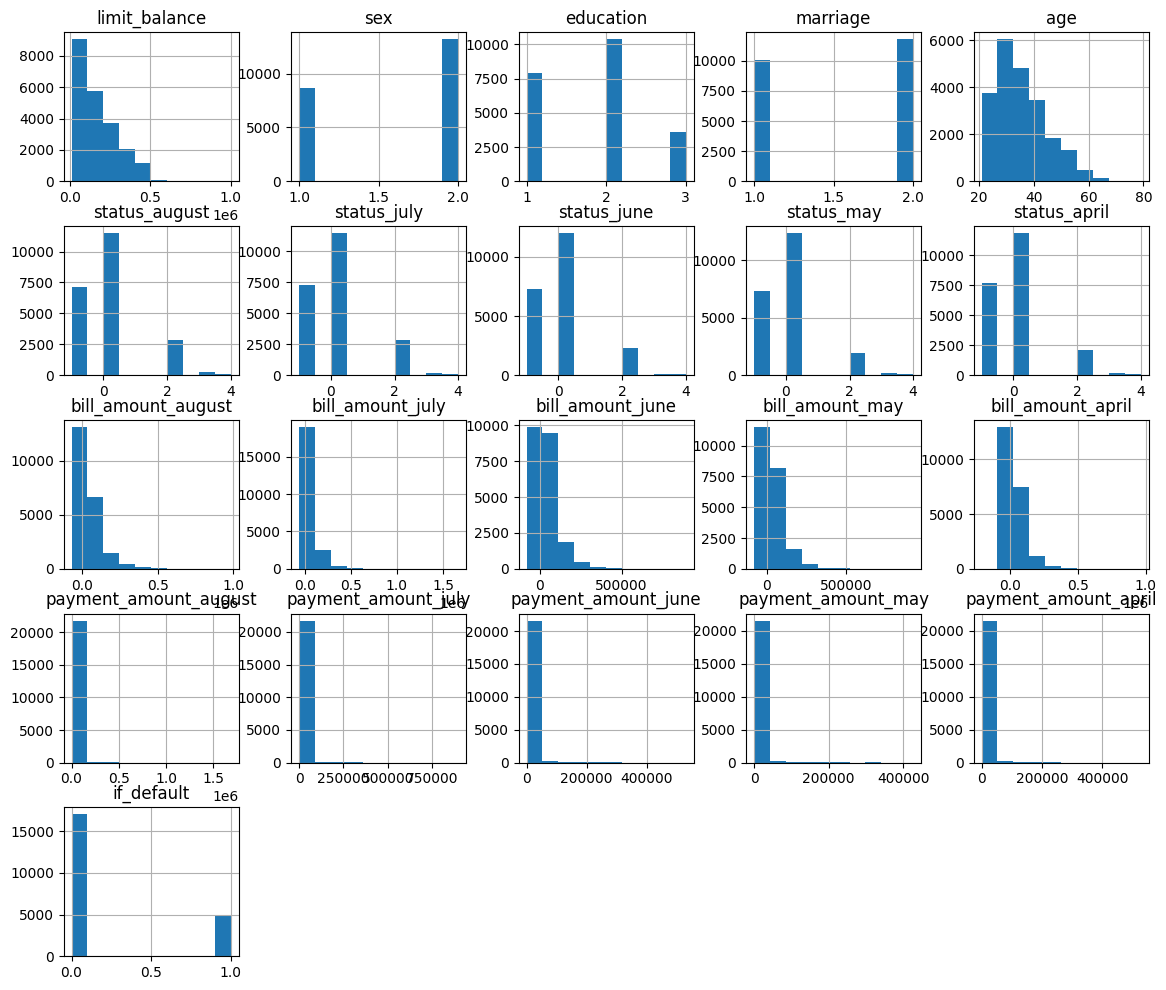

In [ ]:
_ = training_data.hist( figsize=(14,12) )

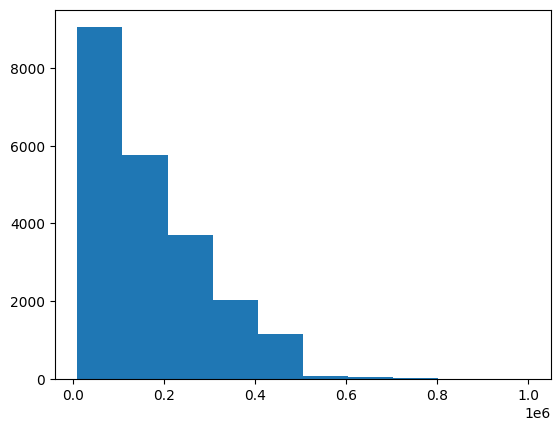

In [ ]:
_=plt.hist(training_data.limit_balance, bins = 10 )

*Что видно на картинке?*

Среди признаков
* 3 являются **бинарными**:  marriage, sex, if_deafault;
* 5 являются **категориальными**: education, status_april, status_may, status_june, status_july, status_august;
* 12 являются **количественными**.

*Напоминание*:
* бинарные признаки - это признаки, которые могут принимать только два значения, например, пол.   
* категориальные признаки - это такие признаки, которые определяют факт принадлежности объекта к некоторой категории. Например, уровень образования у человека, цвет у машины, семейство у животных и т.д.
* количественные признаки - это признаки, которые не являются бинарными или категориальными :)

### Индексация и извлечение данных

Для извлечения отдельного столбца можно использовать конструкцию вида `DataFrame['Name']` или `DataFrame.Name`.

Посмотрим на соотношение людей с дефолтом и без него. Для этого используем метод `value_counts()`, который показывает, сколько каждого вида значений имеется в выборке.


Изобразим графически с помощью столбчатой диаграммы. Для этого у полученного результата вызываем метод `plot()` и передаем в качестве атрибута `kind='bar'`.

In [ ]:
training_data.columns

Index(['limit_balance', 'sex', 'education', 'marriage', 'age', 'status_august',
       'status_july', 'status_june', 'status_may', 'status_april',
       'bill_amount_august', 'bill_amount_july', 'bill_amount_june',
       'bill_amount_may', 'bill_amount_april', 'payment_amount_august',
       'payment_amount_july', 'payment_amount_june', 'payment_amount_may',
       'payment_amount_april', 'if_default'],
      dtype='object')

In [ ]:
#training_data['education'].plot(kind = 'pie')

In [ ]:
training_data['education'].value_counts()

,count
education,
2,10362
1,7889
3,3621


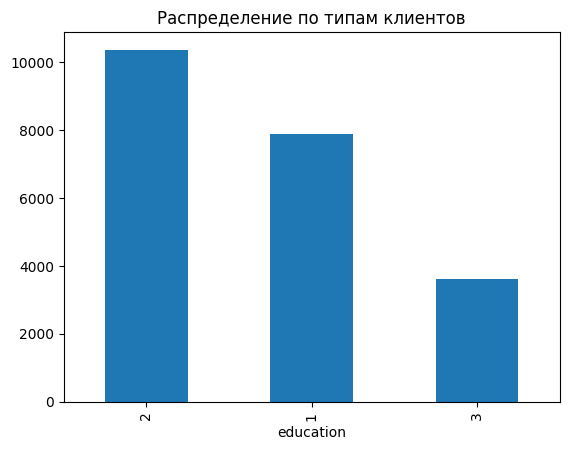

In [ ]:
training_data['education'].value_counts().plot(kind='bar')
plt.title('Распределение по типам клиентов');

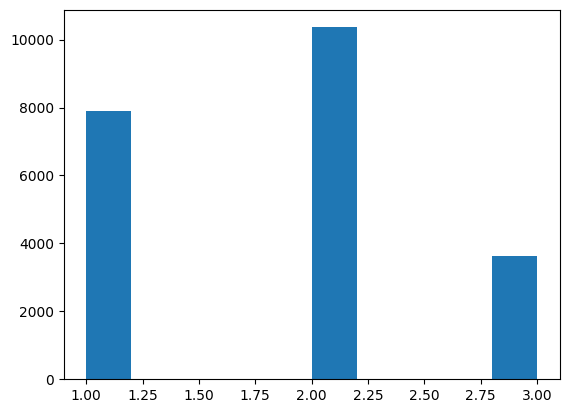

In [ ]:
_ = plt.hist(training_data['education'])

Также можно использовать логическую индексацию DataFrame. Посмотрим на примере: какой максимальный лимит по карте был предоставлен среди пользователей, не вернувших кредит?

Условие для этой задачи будет выглядеть следующим образом:
`training_data['if_default'] == 1`. Максимум ищем с помощью метода max().

In [ ]:
training_data['limit_balance'] < 100000

,limit_balance
0,True
1,False
2,True
3,False
4,False
...,...
21867,False
21868,False
21869,False
21870,False


In [ ]:
training_data[training_data['limit_balance'] < 1000000]['limit_balance'].max()

800000

In [ ]:
training_data['limit_balance'].max()

1000000

Получается, что из данных выбирается та часть, которая удовлетворяет заданному условию, и уже по ней ищется максимум.

**Упражнение.** Найдите медианный возраст группы людей, состоящих в браке. Сравните его с медианным возрастом одиноких людей. Медиану ищем с помощью метода `median()`.

*Подсказка:* замените в коде ниже YOUR_CODE_HERE на правильные значения.

*Напоминание:* Квантиль - это значение, которое заданная случайная величина не превышает с фиксированной вероятностью. $\alpha$-квантиль - это такое число $x_\alpha$, которое удовлетворяет $\mathbf{P}(X \geq x_\alpha) \leq \alpha$. Медиана - это 50% квантиль.

In [ ]:
training_data['marriage'].value_counts()

,count
marriage,
2,11776
1,10096


In [ ]:
training_data[training_data['marriage'] == 1]['age'].mean()

np.float64(40.077357369255154)

In [ ]:
training_data[training_data['marriage'] == 2]['age'].mean()

np.float64(31.448454483695652)

In [ ]:
training_data[training_data['marriage'] == 1]['age'].median()

39.0

In [ ]:
training_data[training_data['marriage'] == 2]['age'].median()

29.0

In [ ]:
training_data.groupby(by= 'marriage')['age'].median()

,age
marriage,
1,39.0
2,29.0


<Axes: xlabel='education'>

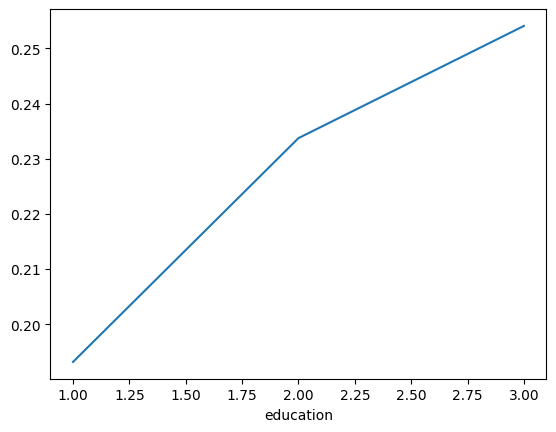

In [ ]:
training_data.groupby('education').if_default.mean().plot()

In [ ]:
training_data.groupby('age').mean().reset_index().head(5)

,age,limit_balance,sex,education,marriage,status_august,status_july,status_june,status_may,status_april,...,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april,if_default
0,21,23000.000000,1.680000,2.000000,1.840000,0.080000,0.200000,0.040000,-0.220000,-0.360000,...,14389.180000,12623.380000,11605.480000,7790.840000,1159.340000,950.480000,1689.280000,735.540000,619.920000,0.180000
1,22,37425.000000,1.742500,1.880000,1.925000,0.432500,0.372500,0.220000,0.157500,0.135000,...,22567.510000,19671.117500,16901.425000,15335.982500,2568.272500,1580.165000,1770.070000,1672.920000,1600.657500,0.322500
2,23,59169.184290,1.720544,1.827795,1.907855,0.223565,0.167674,0.132931,0.084592,0.098187,...,25950.456193,22896.178248,21626.015106,21055.477341,3167.972810,2342.673716,2503.596677,2324.655589,2319.992447,0.264350
3,24,75402.160864,1.672269,1.839136,1.881152,0.222089,0.190876,0.126050,0.093637,0.082833,...,31455.232893,28529.819928,26721.716687,26393.303721,3511.923169,2535.066026,2908.830732,3239.426170,2774.037215,0.271309
4,25,102581.395349,1.674419,1.738372,1.868605,0.145349,0.165116,0.070930,0.040698,0.008140,...,39657.129070,36340.291860,33182.026744,31756.073256,3933.210465,3448.541860,3910.204651,3158.081395,3785.318605,0.246512


<Axes: xlabel='age'>

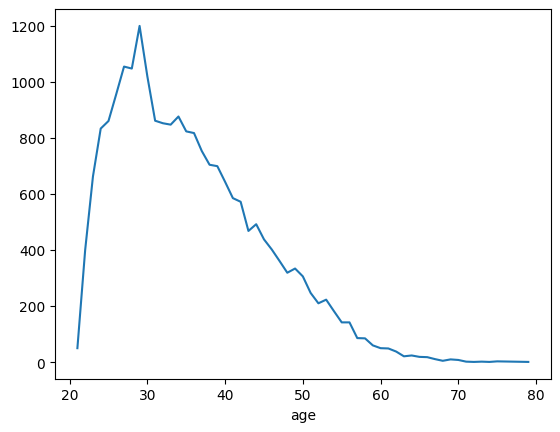

In [ ]:
training_data.groupby('age')['limit_balance'].count().plot()

<Axes: xlabel='age'>

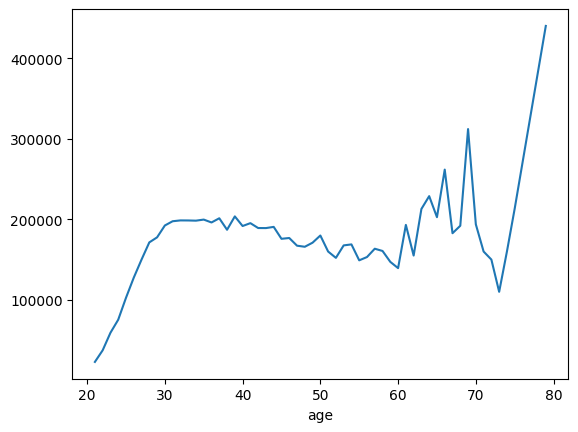

In [ ]:
training_data.groupby('age')['limit_balance'].mean().plot()

In [ ]:
a = []
b = []

for i in range(min(training_data['age']) ,max(training_data['age']+1)):
  a.append( training_data[training_data['age'] == i]['if_default'].mean() )
  b.append( len(training_data[training_data['age'] == i]['if_default']) )

In [ ]:
for i in range(1 ,10):
  print(i)

1
2
3
4
5
6
7
8
9


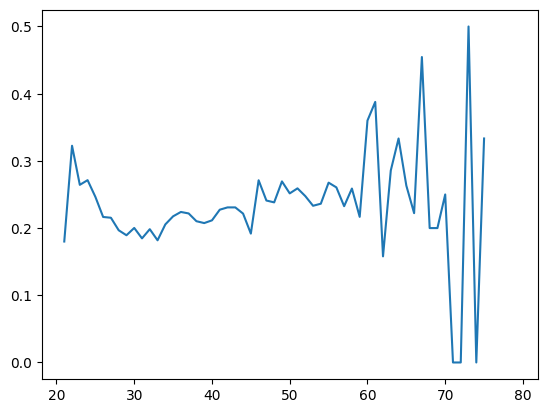

In [ ]:
plt.plot(list(range(min(training_data['age']) ,max(training_data['age']+1))) , a)
#plt.plot(list(range(min(training_data['age']) ,max(training_data['age']))) , b)

ValueError: x and y must have same first dimension, but have shapes (58,) and (59,)

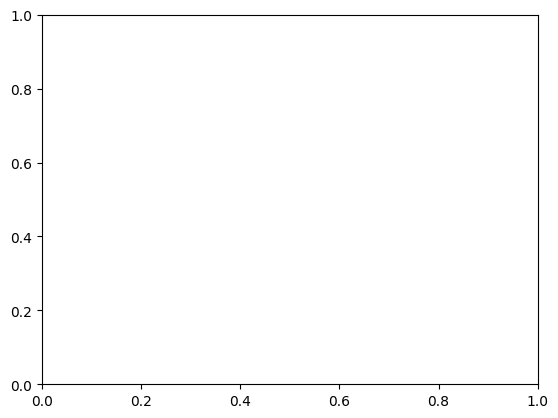

In [ ]:
plt.plot(list(range(min(training_data['age']) ,max(training_data['age']))) , b)

In [ ]:
training_data[(training_data['marriage'] == 1) & (training_data['if_default'] == 0)]

,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,...,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april,if_default
0,60000,2,2,1,40,2,2,0,0,0,...,56363,47940,30134,31144,0,3000,1083,1500,1500,0
1,230000,2,2,1,37,0,0,0,0,0,...,16884,17620,18353,18901,1300,1001,1000,1000,1000,0
4,150000,1,3,1,49,0,0,0,0,0,...,36772,4521,6452,6742,3000,3000,2000,378,3306,0
5,290000,2,1,1,36,-1,-1,-1,-1,-1,...,4536,6074,0,817,4538,6074,0,817,1662,0
6,30000,1,2,1,30,0,0,0,0,0,...,28998,29480,29500,0,2000,1200,1000,0,1500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21864,60000,2,2,1,35,0,0,0,0,0,...,53054,47933,29254,29981,2600,2000,1200,1200,1500,0
21865,100000,1,1,1,43,0,0,0,0,0,...,45522,46832,37683,28680,3000,2500,2000,2000,2000,0
21866,50000,1,2,1,47,0,0,0,0,0,...,26568,26414,26263,27076,1500,1000,1000,2000,2500,0
21867,230000,2,1,1,30,0,0,0,0,0,...,5305,5661,3935,4460,3116,1000,2000,2000,2000,0


In [ ]:
len(training_data)

21872

### Группировка данных и много визуального анализа

Иногда необходимо смотреть на распределение данных по группам, для этого в `pandas` есть группировка. В общем случае группировка выглядит следующим образом:

```
data.groupby(by=имя_колонки_по_которой_группируем).функция_которую_применяем()
```

Посмотрим на общую статистику по возрасту клиентов, но в зависимости от значения целевой переменной. Для отображения общей статистики данных используется функция `describe()`.

In [ ]:
training_data.describe()

,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,...,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april,if_default
count,21872.000000,21872.000000,21872.000000,21872.000000,21872.000000,21872.000000,21872.000000,21872.000000,21872.000000,21872.000000,...,2.187200e+04,21872.000000,21872.000000,21872.000000,2.187200e+04,21872.000000,21872.000000,21872.000000,21872.000000,21872.000000
mean,168114.195318,1.602917,1.804865,1.538405,35.431511,-0.006721,-0.030678,-0.079782,-0.118005,-0.130029,...,4.743392e+04,43726.335955,40967.647266,39677.134784,5.960042e+03,5070.449387,4883.891688,4884.322970,5080.619514,0.222476
std,129762.975164,0.489305,0.698705,0.498534,9.206309,1.019942,1.000764,0.945107,0.903572,0.912880,...,6.990458e+04,64766.199652,61631.645624,60498.457268,2.371555e+04,16495.087514,15812.623267,15418.621808,16605.974804,0.415919
min,10000.000000,1.000000,1.000000,1.000000,21.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-6.150600e+04,-81334.000000,-81334.000000,-209051.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2.666250e+03,2338.750000,1804.500000,1318.250000,8.360000e+02,390.000000,300.000000,275.750000,103.500000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.021900e+04,19197.000000,18281.000000,17346.000000,2.010000e+03,1800.000000,1500.000000,1538.500000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.063475e+04,55622.750000,51005.000000,49920.000000,5.000000e+03,4512.750000,4060.000000,4188.750000,4006.250000,0.000000
max,1000000.000000,2.000000,3.000000,2.000000,79.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,1.684259e+06,896040.000000,528897.000000,426529.000000,527143.000000,1.000000


In [ ]:
a.mean().if_default.plot()

AttributeError: 'list' object has no attribute 'mean'

In [ ]:
a = training_data.groupby(by='age')[['if_default' , 'marriage']].mean()

<Axes: xlabel='age'>

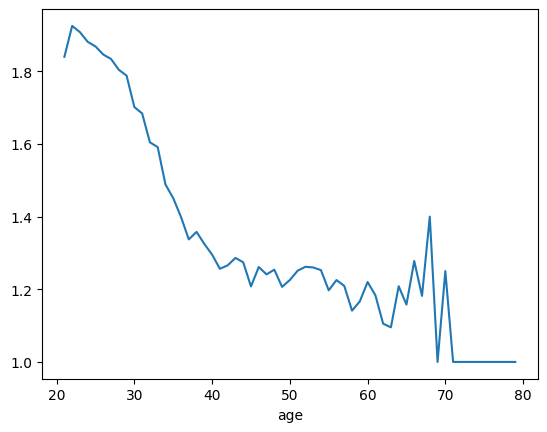

In [ ]:
a.marriage.plot()

In [ ]:
type(a.mean().marriage)

numpy.float64

In [ ]:
training_data.head()

,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,...,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april,if_default
0,60000,2,2,1,40,2,2,0,0,0,...,56363,47940,30134,31144,0,3000,1083,1500,1500,0
1,230000,2,2,1,37,0,0,0,0,0,...,16884,17620,18353,18901,1300,1001,1000,1000,1000,0
2,20000,2,2,2,22,2,0,0,0,3,...,7872,9077,10989,10529,1500,1500,2225,0,0,1
3,150000,2,1,2,29,0,0,0,0,0,...,53030,65006,50515,0,16000,12376,1109,0,0,0
4,150000,1,3,1,49,0,0,0,0,0,...,36772,4521,6452,6742,3000,3000,2000,378,3306,0


In [ ]:
training_data.groupby(by='education')['if_default'].count()

,if_default
education,
1,7889
2,10362
3,3621


Видим, что средний возраст по обеим группам примерно одинаков. То же самое можно сделать и визуально, с помощью инструмента "ящик с усами". Ящик с усами - это компактное отображение распределения данных. Сам ящик ограничен минимальным и максимальным значениями выборки, линия внутри - это медиана, а вне ящика показаны выбросы.

Посмотрим на распределение параметра limit_balance. Для этого используем метод `boxplot()`, в качестве атрибутов подается `column='limit_balance'` (признак, который смотрим), `by='if_default'boxplot` (признак, по которому группируем). Также указываем `figsize=(10,6)`, чтобы отображалось красиво.

<Axes: >

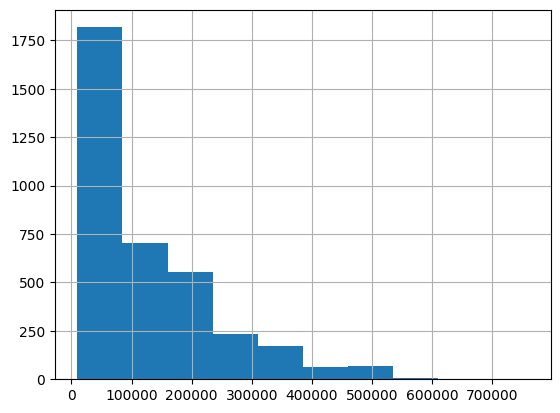

In [ ]:
training_data[training_data['education'] == 3].limit_balance.hist()

<Axes: title={'center': 'limit_balance'}, xlabel='education'>

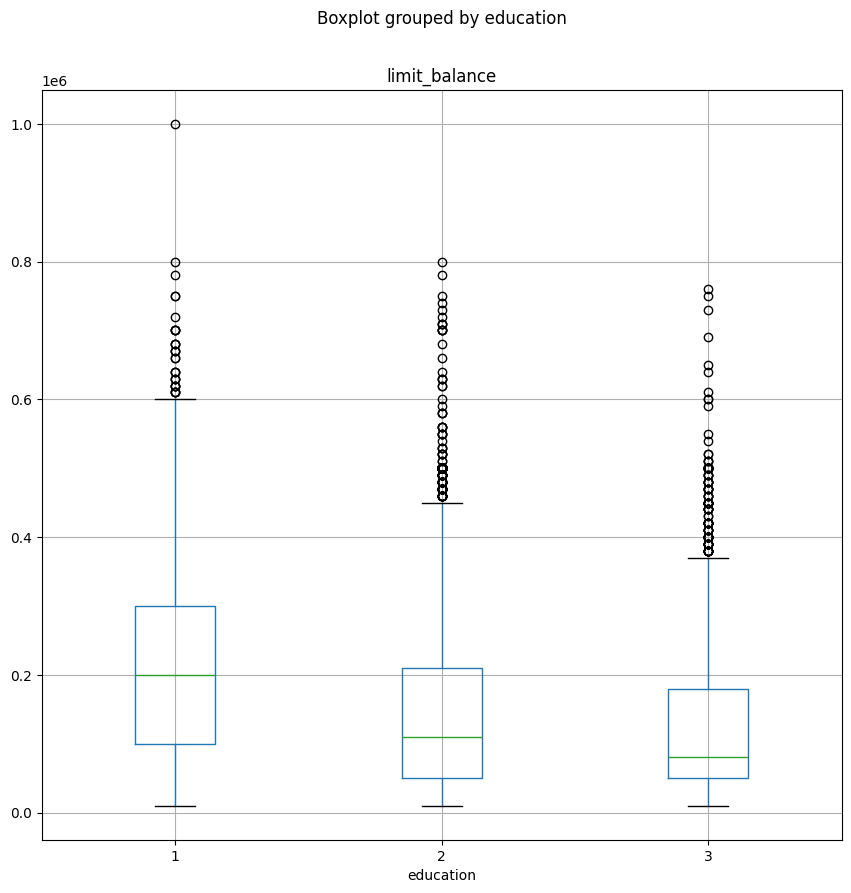

In [ ]:
training_data.boxplot(figsize=(10,10), column='limit_balance', by='education')

*Обратите внимание, что масштаб оси OY 1e6*.

Получается, что лимит тех, кто не вернул кредит в среднем меньше, чем лимит тех, кто его вернул. Это видно по зеленым линиям - медианам. Возможно, банк изначально закладывал "ненадежность" клиента в лимит.  

Посмотрим на гистограммы категориальных признаков marriage и education в зависимости от целевой переменной. Для этого используем метод hist() с теми же атрибутами, что и у метода `boxplot()`. Единственное отличие - так как в наших данных разное количество клиентов в каждой группе, мы хотим сравнивать относительные величины. Устанавливаем `density=True` и получаем одинаковый масштаб в обеих гистограммах.

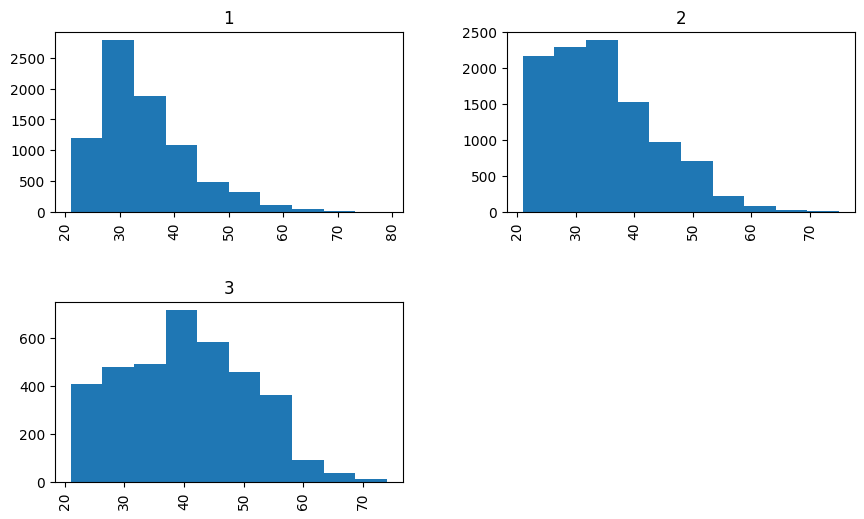

In [ ]:
training_data.hist(figsize=(10,6), column='age', by='education', density=False);

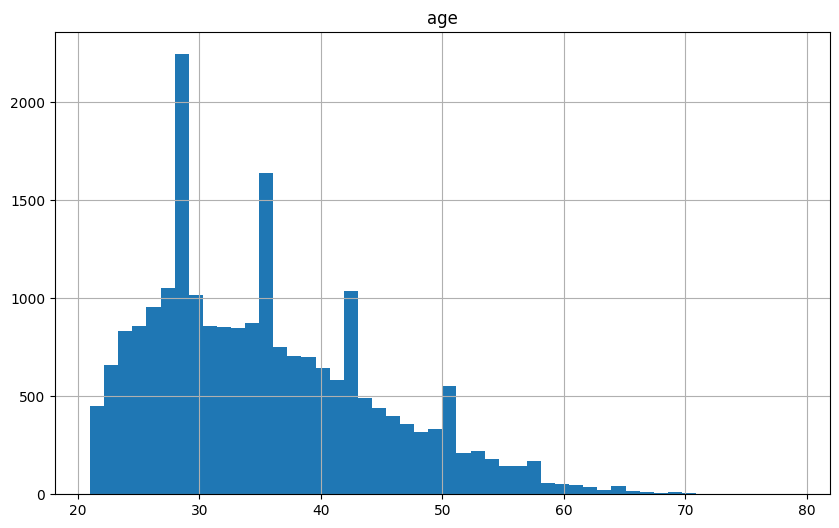

In [ ]:
training_data.hist(figsize=(10,6), column='age' , bins = 50);

Одинокие люди немного чаще не возвращают кредит. Люди с законченной магистратурой, наоборот, чаще долги возвращают.

**Упражнение.** Посмотрите на распределения апрельских статусов клиентов (переменная status_april) в зависимости от целевой переменной. Какой можно сделать вывод?

*Подсказка:* замените в коде ниже YOUR_CODE_HERE на правильные значения.

In [ ]:
training_data

,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,...,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april,if_default
0,60000,2,2,1,40,2,2,0,0,0,...,56363,47940,30134,31144,0,3000,1083,1500,1500,0
1,230000,2,2,1,37,0,0,0,0,0,...,16884,17620,18353,18901,1300,1001,1000,1000,1000,0
2,20000,2,2,2,22,2,0,0,0,3,...,7872,9077,10989,10529,1500,1500,2225,0,0,1
3,150000,2,1,2,29,0,0,0,0,0,...,53030,65006,50515,0,16000,12376,1109,0,0,0
4,150000,1,3,1,49,0,0,0,0,0,...,36772,4521,6452,6742,3000,3000,2000,378,3306,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21867,230000,2,1,1,30,0,0,0,0,0,...,5305,5661,3935,4460,3116,1000,2000,2000,2000,0
21868,290000,1,1,2,35,-1,-1,-1,-1,-1,...,97606,76053,53994,31812,3400,2588,1696,1113,1647,1
21869,310000,1,1,2,30,-1,-1,-1,-1,-1,...,1284,1088,892,-304,1000,1000,1000,304,39544,0
21870,300000,2,1,2,45,0,0,0,0,0,...,125120,133997,118000,131067,10048,20172,11034,20109,30428,0


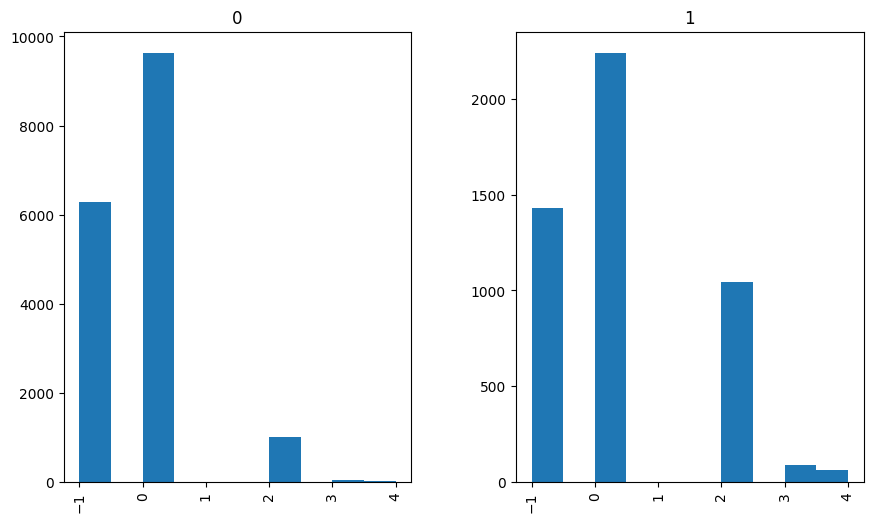

In [ ]:

training_data.hist(figsize=(10,6), column='status_april', by='if_default');

Методы визуализации, которые мы использовали выше (`hist()`, `plot()`, `boxplot()`), основаны на методах из библиотеки **Matplotlib**, но используют их неявно. С одной стороны, благодаря этому мы можем не беспокоиться о том, как аккуратно передать данные в функции, но, с другой стороны, это ограничивает возможности настройки графиков.

Посмотрим на то, какие параметры можно настраивать в методах **Matplotlib** непосредственно.

Проанализируем изменение средних выплат с апреля по май (параметры payment_amount_month).

In [ ]:
mean_amount_payment = training_data[['payment_amount_april', 'payment_amount_may', 'payment_amount_june',
                                     'payment_amount_july', 'payment_amount_august']].mean()

mean_amount_payment

,0
payment_amount_april,5080.619514
payment_amount_may,4884.322970
payment_amount_june,4883.891688
payment_amount_july,5070.449387
payment_amount_august,5960.041971



Основная функция, которая нам нужна - `plot()`. Если ей на вход передать один список, то значения из этого списка будут отложены по оси ординат, а по оси абсцисс будут отложены индексы элементов массива.

*Комментарий:* чтобы задать значения по обеим осям необходимо в `plot()` передать два списка с x-координатами и y-координатами соответственно.

Полезные методы:
* title() - настраивает заголовок графика;
* xticks(), yticks() - настраивают метки осей;
* xlabel(), ylabel() - настраивают подписи к осям (не путать с метками!);
* legend() - включает легенду;
* grid() - включает сетку.



In [ ]:
import numpy as np

In [ ]:
c = np.linspace(-10 , 10 , 1000)

In [ ]:
def f(x):
  return x**3 + x**2 - 3*x+20

In [ ]:
b = f(c)

In [ ]:
a = np.array(range(10))

In [ ]:
a = a-5

In [ ]:
b = a**2

In [ ]:
b

array([25, 16,  9,  4,  1,  0,  1,  4,  9, 16])

In [ ]:
'-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

('-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted')

In [ ]:
def f(x):
  return 0.02*x**3 - 4*x**2 - 3*x+20
b = f(c)

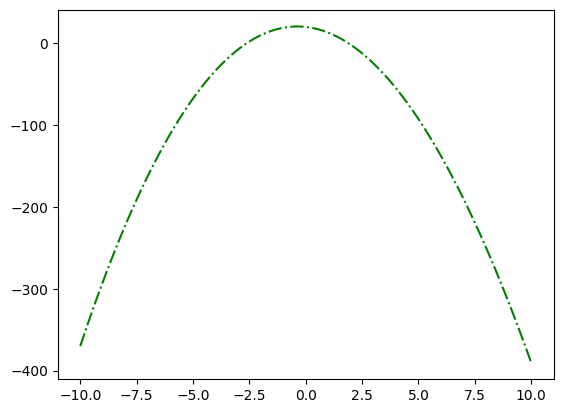

In [ ]:
plt.plot(c , b , color='green', linestyle='-.' )

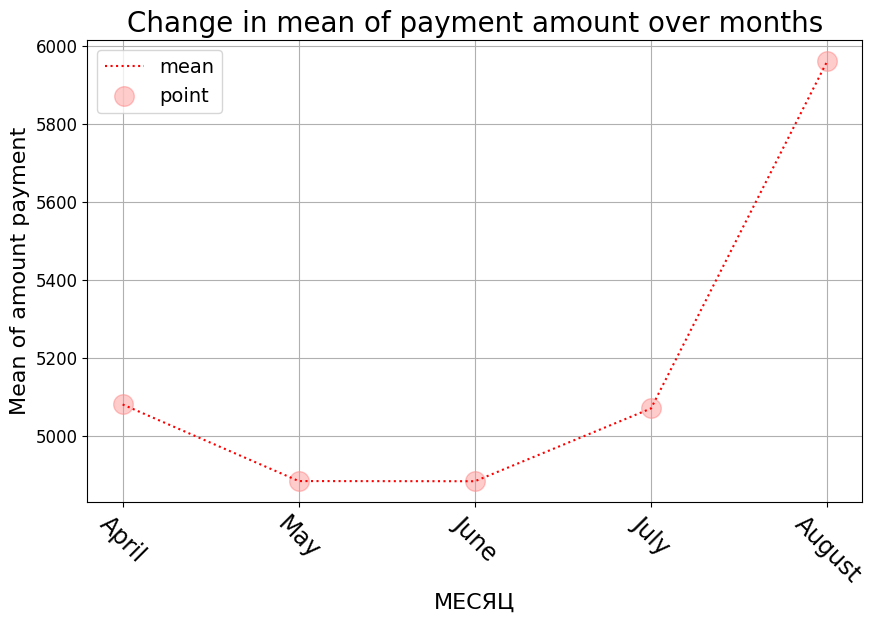

In [ ]:
# инициализируем фигуру и указываем ее размер
plt.figure(figsize=(10, 6))

# строим график
plt.plot(mean_amount_payment, color='red', linestyle=':', label='mean')

plt.scatter(  [0, 1, 2, 3, 4] , mean_amount_payment, color='r', label='point',s=200,alpha=0.2 )
# настраиваем метки осей

plt.xticks(ticks=[0, 1, 2, 3, 4],
           labels=('April', 'May', 'June', 'July', 'August'),
           rotation=-45, fontsize=17);
plt.yticks(fontsize=12);

# название графика
plt.title('Change in mean of payment amount over months', fontsize=20)

# настраиваем подписи осей
plt.ylabel('Mean of amount payment', fontsize=16)
plt.xlabel('МЕСЯЦ', fontsize=16)
# включаем легенду и сетку
plt.legend(fontsize=14)
plt.grid()
plt.show()

**Промежуточные выводы по первичному анализу данных**

* Задача несбалансирована: людей, оплативших долг намного больше.
* Из соц.-дем. характеристик возраст выглядит наименее значимым для построения модели.
* Распределения семейного положения и уровня образования отличаются между группами "дефолтных" и "не дефолтных" клиентов.
* Доступные лимиты по картам существенно различаются между группами.

# Обзор результатов части 1

На этом семинаре мы:
* познакомились с рабочей средой Colab для Data Sсience;
* на примере практической задачи поработали с основными библиотеками Pandas и Matplotlib;
* проделали шаг 1 пайплайна анализа данных, а именно загрузку и визуальный анализ данных.

Научились:
* загружать библиотеки, необходимые для работы;
* загружать данные, представленные в формате csv таблицы;
* понимать, какой размер у выборки данных, какие типы имеют признаки;
* индексировать и группировать данные;
* смотреть различные статистики по данным;
* строить гистограммы и боксплоты.


<a target="_blank"><img src="https://pbs.twimg.com/media/DctMkmjXUAY8I7P.jpg"
alt="IMAGE ALT TEXT HERE" width="620" border="0" /></a>




---



# Часть 2. Обучение и тестирование модели.

После того, как мы загрузили данные, посмотрели на них глазами, сделали какие-то выводы, можно переходить непосредственно к машинному обучению.

**Напоминание:** не забудьте снова загрузить библиотеки и данные.

In [ ]:
training_data.shape

(21872, 21)

In [ ]:
test_data.shape

(7291, 21)

## 2.Подготовка данных для обучения и тестирования. Работаем с целевой переменной

*Какая переменная целевая?*

В данном случае по условию задачи мы должны прогнозировать дефолт, поэтому целевая переменная - это наличие дефолта, **if_default**.

Нам нужно выделить в отдельную переменную столбец из нашей таблицы, который соответствует определенной выше целевой переменной.

Для этого мы у таблицы `training_data` в квадратных скобках указываем имя нужного столбца.

In [ ]:
training_values = training_data['if_default']

Проверим размерность целевой переменной. Это можно сделать с помощью метода `shape`:

In [ ]:
training_values.shape

(21872,)

In [ ]:
training_data['if_default'].shape

(21872,)

In [ ]:
training_values[:20]

,if_default
0,0
1,0
2,1
3,0
4,0
5,0
6,0
7,0
8,0
9,0


Запись `(21872,)` равносильна `(21872, 1)`.  Она означает, что у нас 21872 столбцов (экземпляров в выборке) и 1 колонка (признак)

Отделим входные переменные от целевой, чтобы можно было построить модель предсказания целевой переменной по входным.


Для это нужно будем использовать метод ```drop()```.

Обратите внимание, что в данном случае мы передаем два аргумента:
* target_variable_name - название столбца цены, который мы ранее записали в эту переменную и теперь хотим удалить из training_data
* axis=1 - означает, что мы удаляем столбец, а в случае axis=0 - означает, что мы удаляем строку

In [ ]:
training_data.head()

,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,...,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april,if_default
0,60000,2,2,1,40,2,2,0,0,0,...,56363,47940,30134,31144,0,3000,1083,1500,1500,0
1,230000,2,2,1,37,0,0,0,0,0,...,16884,17620,18353,18901,1300,1001,1000,1000,1000,0
2,20000,2,2,2,22,2,0,0,0,3,...,7872,9077,10989,10529,1500,1500,2225,0,0,1
3,150000,2,1,2,29,0,0,0,0,0,...,53030,65006,50515,0,16000,12376,1109,0,0,0
4,150000,1,3,1,49,0,0,0,0,0,...,36772,4521,6452,6742,3000,3000,2000,378,3306,0


In [ ]:
training_points = training_data.drop(columns=['if_default'])

In [ ]:
training_points.shape

(21872, 20)

In [ ]:
training_points.head(5)

,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,bill_amount_august,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april
0,60000,2,2,1,40,2,2,0,0,0,58381,56363,47940,30134,31144,0,3000,1083,1500,1500
1,230000,2,2,1,37,0,0,0,0,0,15849,16884,17620,18353,18901,1300,1001,1000,1000,1000
2,20000,2,2,2,22,2,0,0,0,3,6643,7872,9077,10989,10529,1500,1500,2225,0,0
3,150000,2,1,2,29,0,0,0,0,0,49300,53030,65006,50515,0,16000,12376,1109,0,0
4,150000,1,3,1,49,0,0,0,0,0,37293,36772,4521,6452,6742,3000,3000,2000,378,3306


In [ ]:
training_points = training_data.drop('if_default', axis=1)

In [ ]:
a = ['if_default' , 'bill_amount_may']

In [ ]:
tr = training_data.drop(columns=a)

In [ ]:
training_points.head()

,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,bill_amount_august,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april
0,60000,2,2,1,40,2,2,0,0,0,58381,56363,47940,30134,31144,0,3000,1083,1500,1500
1,230000,2,2,1,37,0,0,0,0,0,15849,16884,17620,18353,18901,1300,1001,1000,1000,1000
2,20000,2,2,2,22,2,0,0,0,3,6643,7872,9077,10989,10529,1500,1500,2225,0,0
3,150000,2,1,2,29,0,0,0,0,0,49300,53030,65006,50515,0,16000,12376,1109,0,0
4,150000,1,3,1,49,0,0,0,0,0,37293,36772,4521,6452,6742,3000,3000,2000,378,3306


In [ ]:
training_points = training_data.drop(columns='if_default')

Можно посмотреть результаты этих действий с помощью ```head()``` и ```shape```, которыми мы пользовались ранее,  но сейчас нужно вызывать их от новых переменных.

In [ ]:
training_points.head()

,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,bill_amount_august,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april
0,60000,2,2,1,40,2,2,0,0,0,58381,56363,47940,30134,31144,0,3000,1083,1500,1500
1,230000,2,2,1,37,0,0,0,0,0,15849,16884,17620,18353,18901,1300,1001,1000,1000,1000
2,20000,2,2,2,22,2,0,0,0,3,6643,7872,9077,10989,10529,1500,1500,2225,0,0
3,150000,2,1,2,29,0,0,0,0,0,49300,53030,65006,50515,0,16000,12376,1109,0,0
4,150000,1,3,1,49,0,0,0,0,0,37293,36772,4521,6452,6742,3000,3000,2000,378,3306


In [ ]:
#training_points['if_default']

In [ ]:
training_points.shape

(21872, 20)

Видно, что столбца действительно нет, а количество строк не изменилось.

**Упражнение**. По аналогии подготовьте тестовую выборку. Не забудьте проверить, что все получилось правильно.

*Подсказка:* замените в коде ниже YOUR_CODE_HERE на правильные значения.

In [ ]:
test_values = test_data['if_default']
test_points = test_data.drop(columns= 'if_default')


# YOUR_CODE_HERE
print(test_points.shape)



(7291, 20)


In [ ]:
print(test_values.shape)

(7291,)


<a target="_blank"><img src="https://1.bp.blogspot.com/-Sk5yumiKjAQ/XO4S7ocnHXI/AAAAAAAADCA/mw_XfK7ICdgr_NjzR1h8e8PJ1k7Gg3mGwCLcBGAs/s1600/programing-ml.png"
alt="IMAGE ALT TEXT HERE" width="620" border="0" /></a>

## 3.1. Выбираем метод, который будем использовать

Проще всего начать с простых методов.
Мы воспользуемся двумя методами для построения моделей и сравним их между собой:
* Логистическая регрессия *logistic regression*
* Лес решающих деревьев *random forest*

Логистическая регрессия - "адаптация" линейной регрессии для решения задачи классификации. Она принадлежит к классу обобщенных линейных моделей.

На выбор метода для построения модели влияет набор признаков, размер выборки, интуиция про то, какая связь между входными переменными и целевой. Но часто решение принимается исходя из того, какая модель сработала лучше.

Библиотека **scikit-learn** де факто наиболее популярный, разносторонний, хорошо документированный и постоянно обогащающийся инструмент для построения моделей машинного обучения.

<a target="_blank"><img src="https://neurohive.io/wp-content/uploads/2019/06/1200px-Scikit_learn_logo_small.svg.png"
alt="IMAGE ALT TEXT HERE" width="360" border="0" /></a>


Мы импортируем два модуля из этой библиотеки:
* linear_model - тут находятся все линейные модели и обобщенные линейные модели, в том числе модель логистической регрессии.
* ensemble - тут находятся модели на основе ансамблей


In [ ]:
from sklearn import linear_model, ensemble
from sklearn.neighbors import KNeighborsClassifier

**Sklearn** всем хорош, но он печатает много различных предупреждений в процессе работы.

Библиотека warnings отвечает за то, какие предупреждения о работе будут выводиться пользователю. FutureWarning - предупреждения о том, как изменится работа библиотек в будущих версиях.

Включим режим игнорирования таких предупреждений. Это делается вызовом функции simplefilter() c задание двух атрибутов: действия action и категории предупреждений category.

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
from sklearn import *

Прежде чем начать делать ремонт, нужно подготовить инструменты для работы. Аналогично в нашем случае, прежде чем обучать модели, нужно создать их прототипы.

Чтобы создать модель логистической регрессии, пишем имя модуля `linear_model`, затем точку, затем название модели.

Для этого нужно выполнить следующий код:

```python
logistic_regression_model = linear_model.LogisticRegression()
logistic_regression_model
```

Результат выполнения должен быть следующим:

```python
LogisticRegression(C=1.0, class_weight=None, dual=False,
          fit_intercept=True, intercept_scaling=1,
          max_iter=100, multi_class='warn', n_jobs=None,
          penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)
```

In [ ]:
logistic_regression_model = linear_model.LogisticRegression() # создаем модель
logistic_regression_model # смотрим, что получилось

LogisticRegression()

In [ ]:
type(logistic_regression_model)

sklearn.linear_model._logistic.LogisticRegression

По аналогии создаем модель случайного леса auto`RandomForestClassifier()` из модуля `ensemble`.

Для этого нужно выполнить следующий код:

```python
random_forest_model = ensemble.RandomForestClassifier()
random_forest_model
```

Результат выполнения должен быть следующим:
    
```python
RandomForestClassifier(bootstrap=True, class_weight=None,
            criterion='gini', max_depth=None, max_features='auto',
            max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn',
            n_jobs=None, oob_score=False, random_state=None,
            verbose=0, warm_start=False)
```

В качестве атрибутов передаем параметр `n_estimators=100`.

In [ ]:
random_forest_model = ensemble.RandomForestClassifier(n_estimators=100)
random_forest_model

RandomForestClassifier()

In [ ]:
KNN_model = KNeighborsClassifier()
KNN_model

KNeighborsClassifier()

У модели классификации на основе случайного леса больше **гиперпараметров**,чем у логистической регрессии. Рассмотрим наиболее важные:
* гиперпараметр **n_estimators** определяет, сколько деревьев в лесу,
* в гиперпараметре **max_depth** устанавливается, какая максимальная глубина у дерева,
* в гиперпараметре **min_samples_leaf** задается, какое минимальное число объектов может попасть в лист дерева.


*Замечание:* Конкретные значения оказывают влияние на время обучения: например, чем больше деревьев в лесе - тем больше время обучения. Чем больше параметров у модели, тем дольше она обучается.

## 3.2. Обучить модель

Теперь, когда мы создали прототипы обеих моделей, можем их обучить с помощью обучающей выборки.

Для этого вызываем метод ```fit()``` у модели и передаем ему на вход два аргумента: таблицу входных признаков и столбец значений целевой переменной - (training_points, training_values)

In [ ]:
training_points.shape

(21872, 20)

In [ ]:
logistic_regression_model.fit(training_points, training_values)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
logistic_regression_model.coef_

array([[-5.10693949e-06, -7.16885333e-05, -8.22360840e-05,
        -7.44797524e-05, -1.27714336e-03,  7.03311061e-05,
         5.61817697e-05,  5.15560931e-05,  4.87949184e-05,
         4.42052847e-05, -7.40313154e-06, -1.16566529e-06,
         7.36683353e-06,  4.19728523e-06,  1.41123449e-06,
        -3.22417691e-05, -3.71671360e-05, -1.18696082e-05,
        -1.18795934e-05, -3.07160682e-06]])

Делаем тоже самое для модели решающего леса.

In [ ]:
random_forest_model.fit(training_points, training_values)

RandomForestClassifier()

* Для двух разных моделей в sklearn методы для обучения модели не отличаются.
* Мы получили две обученные модели.
* Теперь необходимо провалидировать модели на новых тестовых данных, которые не использовались при обучении модели.

In [ ]:
KNN_model.fit(training_points, training_values)
test_predictions_KNN = KNN_model.predict(test_points)

# 4.Провалидировать модель на тестовой выборке

<img src="https://drive.google.com/uc?id=1QbHrix_UrbD77BmIGiitiaH8nB8UdUmj" alt="Drawing" style="width: 400px;"/>


Сначала получим прогноз модели на тестовых данных `test_points` с помощью моделей логистической регрессии и решающего леса.
Для этого для обеих моделей запустим метод `predict()`.

In [ ]:
logistic_regression_model

LogisticRegression()

In [ ]:
test_points.shape

(7291, 20)

In [ ]:
test_points.head()

,limit_balance,sex,education,marriage,age,status_august,status_july,status_june,status_may,status_april,bill_amount_august,bill_amount_july,bill_amount_june,bill_amount_may,bill_amount_april,payment_amount_august,payment_amount_july,payment_amount_june,payment_amount_may,payment_amount_april
0,130000,2,2,2,22,0,0,0,0,0,14867,10341,9788,7193,9006,2000,2290,1005,4078,713
1,160000,2,2,1,38,0,0,0,2,2,109030,109731,116452,114481,121885,4002,8565,0,9502,0
2,180000,2,1,2,25,-1,-1,-1,-1,-1,-632,-632,-632,-632,-632,0,0,0,0,0
3,210000,2,2,2,37,0,0,0,0,0,58054,44624,43339,44245,45125,15000,1552,1605,1615,1698
4,600000,2,3,2,51,0,0,0,0,0,78404,147559,323129,310042,311840,85113,217035,11032,15019,10033


In [ ]:
test_predictions_logistic_regression = logistic_regression_model.predict(test_points)

In [ ]:
test_predictions_random_forest = random_forest_model.predict(test_points)

In [ ]:
test_predictions_KNN = KNN_model.predict(test_points)

In [ ]:
test_predictions_random_forest[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0])

In [ ]:
test_points.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7291 entries, 0 to 7290
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   limit_balance          7291 non-null   int64
 1   sex                    7291 non-null   int64
 2   education              7291 non-null   int64
 3   marriage               7291 non-null   int64
 4   age                    7291 non-null   int64
 5   status_august          7291 non-null   int64
 6   status_july            7291 non-null   int64
 7   status_june            7291 non-null   int64
 8   status_may             7291 non-null   int64
 9   status_april           7291 non-null   int64
 10  bill_amount_august     7291 non-null   int64
 11  bill_amount_july       7291 non-null   int64
 12  bill_amount_june       7291 non-null   int64
 13  bill_amount_may        7291 non-null   int64
 14  bill_amount_april      7291 non-null   int64
 15  payment_amount_august  7291 non-null  

**Упражнение.** Посмотрите, сколько предсказаний каждого вида (дефолтов и возвратов кредитов) спрогнозировали модели. Подсказка: количество единичек-дефолтов можно посчитать, просуммировав все значения в массиве предсказанных меток с помощью метода `sum()`. Количество не-дефолтов - это длина массива минус количество дефолтов. Для получения длины массива используйте функцию `len(массив)` или метод `массив.shape[0]`.

*Подсказка:* замените в коде ниже #YOUR_CODE_HERE на правильные значения.

In [ ]:
# YOUR_CODE_HERE
test_predictions_logistic_regression.shape

(7291,)

In [ ]:
# YOUR_CODE_HERE
len(test_predictions_random_forest)

7291

In [ ]:
# YOUR_CODE_HERE
test_predictions_random_forest.sum()/len(test_predictions_random_forest)


np.float64(0.11137018241667809)

**Шаг 5.1. Считаем точность прогноза**

Естественный способ измерить качество модели - посчитать долю правильных предсказаний, то есть, сколько в процентном соотношении от размера тестовой выборки модель угадала единичек и сколько угадала ноликов. Такая метрика называется точность (accuracy).

<img src="https://drive.google.com/uc?id=1ITTp5pCtDKszhkkLXzXiuCWi09VJaioA" alt="Drawing" style="width: 600px;"/>

Функция для подсчета точности реализована в библиотеке **sklearn** и называется **`accuracy_score()`**. Импортируем её.

In [ ]:
test_values.sum()/len(test_values)

np.float64(0.2260320943629132)

In [ ]:
test_values.value_counts()

,count
if_default,
0,5643
1,1648


In [ ]:
from sklearn.metrics import accuracy_score

В функцию **`accuracy_score()`** необходимо передать два аргумента:
* истинные значения меток - *test_values*
* предсказания модели - *test_predictions_logistic_regression* или *test_predictions_random_forest*

In [ ]:
print(accuracy_score(test_values, test_predictions_logistic_regression))
print(accuracy_score(test_values, test_predictions_random_forest))
print(accuracy_score(test_values, test_predictions_KNN))

0.7739679056370868
0.7964613907557262
0.7576464133863667


In [ ]:
test_timur = [0]*len(test_values)

In [ ]:
print(accuracy_score(test_values, test_timur))

0.7739679056370868


In [ ]:
test_predictions_logistic_regression.sum()

np.int64(4)

In [ ]:
test_predictions_random_forest.sum()

np.int64(812)

In [ ]:
test_predictions_KNN.sum()

np.int64(737)

In [ ]:
test_values.sum()/len(test_values)

np.float64(0.2260320943629132)

In [ ]:
test_values.sum()

np.int64(1648)

**Как понять, хорошо работает модель или нет?**

Из значения точности мы никак не можем понять, сколько меток каждого класса правильно предсказала модель. В нашей задаче мало значений с классом 1 (дефолт), но много 0 (возврат долга). Может быть такая ситуация, когда модель очень хорошо научилась выделять характеристики большого класса, в нашем случае 0, но совсем не умеет выделять характеристики маленького класса. А часто именно последние в большей степени интересуют аналитиков.

Самый простой способ проверить - это сравнить значения точности для наших моделей с точностью для константного классификатора, модели, которая всегда бы предсказывала больший класс, в нашем случае 0.
Для этого можно в функцию `accuracy_score()` в качестве второго аргумента передать массив нулей такого же размера, как и *test_values*.

Чтобы получить набор нулей длины как test_values, воспользуемся хитростью Python: создадим лист из одного нуля `[0]`, а затем умножим его на длину `len(test_values)`.  

In [ ]:
sum(test_values)

1648

In [ ]:
(7291 - 1648) / 7291

0.7739679056370868

In [ ]:
len(test_values)

7291

In [ ]:
print(accuracy_score(test_values, [0] * len(test_values)))

0.7739679056370868


In [ ]:
from tqdm import tqdm

In [ ]:
scores_test = []
scores_train = []
for k in tqdm(range(1,100)):
  KNN_model = KNeighborsClassifier(n_neighbors=k)
  KNN_model.fit(training_points, training_values)
  test_predictions_KNN = KNN_model.predict(test_points)
  train_pred = KNN_model.predict(training_points)
  scores_test.append(accuracy_score(test_values, test_predictions_KNN))
  scores_train.append(accuracy_score(train_pred, training_values))
  if k%10 == 0:
    print(k)

 10%|█         | 10/99 [01:00<08:43,  5.88s/it]

10


 20%|██        | 20/99 [01:57<07:35,  5.76s/it]

20


 30%|███       | 30/99 [02:56<06:59,  6.08s/it]

...

 81%|████████  | 80/99 [07:55<01:54,  6.02s/it]

80


 91%|█████████ | 90/99 [08:57<00:55,  6.14s/it]

90


100%|██████████| 99/99 [09:52<00:00,  5.98s/it]


In [ ]:
len(scores_train)

99

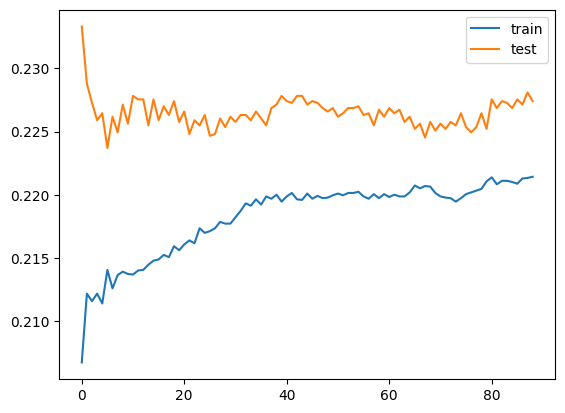

In [ ]:
plt.plot(1-np.array(scores_train[10:]) , label = 'train')
plt.plot(1- np.array(scores_test[10:]) , label = 'test' )
plt.legend()

Действительно, для логистической регрессии точность очень близка к точности константного классификатора. У решающих деревьев точность выше, значит они выявляют более сложные закономерности.  

Чтобы окончательно убедиться, что логистическая регрессия работает плохо, а деревья - хорошо, необходимо проверить дополнительные метрики.

Какие? Узнаем на следующих семинарах!

<a target="_blank"><img src="https://i.pinimg.com/474x/b1/75/35/b1753549d681efd913d138c54b8bf2ea--coming-soon-poster-mod-makeup.jpg" width="480" border="0" /></a>

#Бонус: Прогноз вероятности принадлежности к классу

Вместо прогноза меток классов модель может с помощью метода **`predict_proba()`** выдавать метки вероятности принадлежности к классам.
Так как класса у нас 2: заемщики с дефолтом и без, то матрица будет размером **(количество объектов в тестовой выборке, 2)**.

In [ ]:
test_probabilities = logistic_regression_model.predict_proba(test_points)

Посмотрим на первые пять значений этой матрицы:

In [ ]:
test_probabilities[:5, :]

Вероятность принадлежности ко второму классу - во втором столбце матрицы вероятностей.

In [ ]:
test_probabilities = random_forest_model.predict_proba(test_points)
test_probabilities = test_probabilities[:, 1]

Посмотрим на распределение предсказанной классификатором вероятности дефолта, метки `1`.

In [ ]:
# инициализируем картинку и указываем ее размер
plt.figure(figsize=(8, 5))

# строим распределение вероятностей
plt.hist(test_probabilities, bins=100)

# строим прямую линию в точке 0.5
plt.vlines(0.5, 0, 300)

# подписываем оси
plt.xlabel('Предсказанная вероятность дефолта', fontsize=20)
plt.ylabel('Количество заемщиков', fontsize=20);

Распределение сконцентрировано на отрезке от `0` до `0.3` и лишь незначительная часть вероятностей превышает порог `0.5`. Из
этого можно предположить, что классификатор склонен классифицировать все
объекты скорее как `0`, игнорируя метку `1`. Это происходит потому, что меток `1` в обучающей выборке сильно меньше, чем меток `0`.

In [ ]:
sum(test_probabilities > 0.4)

In [ ]:
print(accuracy_score(test_values,(test_probabilities > 0.4)))

In [ ]:
logistic_regression_model.coef_

---


# Обзор результатов части 2

На этом семинаре мы:
* познакомились с основной библиотекой для машинного обучения Scikit-learn;
* обучили модель логистической регрессии и решающего леса для предсказания дефолта по кредитной карте;
* провалидировали модель на тестовой выборке с помощью метрики accuracy;
* поняли, почему метрика accuracy не всегда хорошо подходит для задач;
* получили и построили распределение вероятностей предсказанных классов.


# Часть 3. Метрики и ансамбли

В этот раз мы рассмотрим такие метрики:
+ Accuracy
+ Precision, recall, F1
+ ROC-AUC
+ PR-AUC

In [ ]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
%matplotlib inline
test_values = test_data['if_default']
test_points = test_data.drop(columns= 'if_default')

In [ ]:
# Импортируем модель K Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=10)
model_knn.fit(training_points, training_values)

# Сделаем предсказания
predictions_knn = model_knn.predict(test_points)
print(predictions_knn[:10])
predictions_knn.shape

In [ ]:
# Еще возьмем модель покруче
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100)
model_rf.fit(training_points, training_values)

# Сделаем предсказания
predictions_rf = model_rf.predict(test_points)
print(predictions_rf[:10])
predictions_rf.shape

## 1. Accuracy

<sub style="font-size:140%; font-style: italic; color:gray;">"Невозможно улучшить что-то, если не можешь это измерить" (с)<sub/>

Теперь, когда у нас есть две модели, хорошо бы оценить их точность, чтобы понять, какая лучше.  

Здесь приходит на помощь метрика:

### $$Accuracy = \frac{\sum_{x_i, y_i \in (X, Y)} I(y(x_i) = y_i)}{|(X, Y)|} = \frac{num~right~classified~obj}{num~all~obj}$$  

In [ ]:
sum(predictions_knn == test_values)/len(predictions_knn)

In [ ]:
from sklearn.metrics import accuracy_score

# первый аргумент всегда y_test, а второй - предсказания
print('KNN accuracy:', accuracy_score(test_values, predictions_knn))
print('RF accuracy:', accuracy_score(test_values, predictions_rf))

In [ ]:
accuracy_score( predictions_knn , test_values)

# Все хорошо, но есть один ньюанс...

In [ ]:
from sklearn.dummy import DummyClassifier

model_dummy = DummyClassifier(strategy = "most_frequent")
model_dummy.fit(training_points, training_values)

predictions_dummy = model_dummy.predict(test_points)

print('Dummy accuracy:', accuracy_score(test_values, predictions_dummy))

In [ ]:
predictions_dummy.sum()

In [ ]:
1 - sum(test_values)/len(test_values)

**Вопрос:** почему такая большая accuracy у такой модели?  

**Вопрос:** значит ли это, что наши модели совсем ненамного лучше, чем ничего?

# 2. Precision, Recall, F1

Метрики, предназначенные для работы с несбалансированными классами.  
F1 вообще наиболее распространенная метрика для классификации.

# Precision

## $$Precision = \frac{TP}{TP + FP}$$

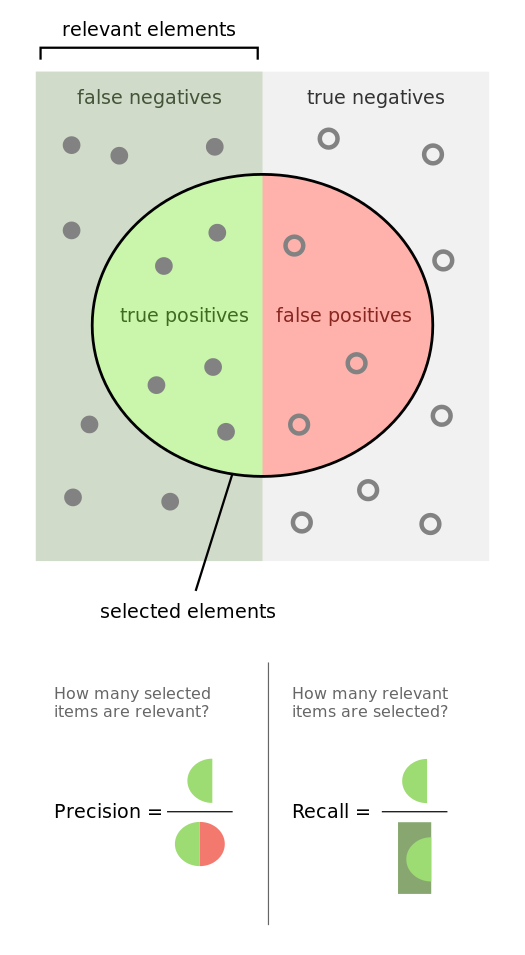

In [ ]:
from sklearn.metrics import precision_score

print('KNN precision:', precision_score(test_values, predictions_knn))
print('RF precision:', precision_score(test_values, predictions_rf))
print('Dummy precision:', precision_score(test_values, predictions_dummy) );

# Recall

## $$Recall = \frac{TP}{TP + FN}$$

In [ ]:
from sklearn.metrics import recall_score

print('KNN recall:', recall_score(test_values, predictions_knn))
print('RF recall:', recall_score(test_values, predictions_rf))
print('Dummy recall:', recall_score(test_values, predictions_dummy))

In [ ]:
from sklearn.metrics import recall_score

print('KNN recall:', recall_score( predictions_knn, test_values))
print('RF recall:', recall_score(predictions_rf, test_values))
print('Dummy recall:', recall_score(predictions_dummy, test_values))

# F_1 score

In [ ]:
from sklearn.metrics import f1_score

print('KNN f_1:', f1_score(test_values, predictions_knn))
print('RF f_1:', f1_score(test_values, predictions_rf))
print('Dummy f_1:', f1_score(test_values, predictions_dummy))


# Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix

b = confusion_matrix(test_values, predictions_rf)

In [ ]:
b

In [ ]:
confusion_matrix(test_values, predictions_rf)

In [ ]:
import seaborn as sns

In [ ]:
sns.heatmap(
   b
);

In [ ]:
import seaborn as sns

fig = plt.figure(figsize=(6,5))

plt.title('Confusion matrix for Random Forest')
plt.ylabel("Real value", fontsize=14)
plt.xlabel("Predicted value", fontsize=14)

sns.heatmap(
    confusion_matrix(test_values, predictions_rf).T,
    annot=True, fmt="d",
    xticklabels=['default', 'not_default'],
    yticklabels=['default', 'not_default']
);

In [ ]:
fig = plt.figure(figsize=(6,5))

plt.title('Confusion matrix for KNN')
plt.ylabel("Real value", fontsize=14)
plt.xlabel("Predicted value", fontsize=14)

sns.heatmap(
    confusion_matrix(test_values, predictions_knn).T,
    annot=True, fmt="d",
    xticklabels=['default', 'not_default'],
    yticklabels=['default', 'not_default']
);

In [ ]:
fig = plt.figure(figsize=(6,5))

plt.title('Confusion matrix for Dummy Classifier')
plt.ylabel("Real value", fontsize=14)
plt.xlabel("Predicted value", fontsize=14)

sns.heatmap(
    confusion_matrix(test_values, predictions_dummy).T,
    annot=True, fmt="d",
    xticklabels=['default', 'not_default'],
    yticklabels=['default', 'not_default']
);

Precision и Recall сами по себе не говорят о качестве модели. Нужно как-то их объединить.

Если их просто перемножить, будет не очень. **Почему?**  
Если взять среднее от них, будет не очень. **Почему?**  
Если взять минимальное из двух, будет не очень. **Почему?**  

# F1 score
А вот если...
## $$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [ ]:
import scipy

fig, axs = plt.subplots(figsize=(18, 5), ncols=3)

x_, y_ = np.arange(0.01, 1, 0.01), np.arange(0.01, 1, 0.01)
X, Y = np.meshgrid(x_, y_)

Z = [[0.5*x + 0.5*y  for x in x_] for y in y_]
axs[0].contour(X, Y, Z)
axs[0].set_title('mean')
axs[0].set_xlabel('Presition')
axs[0].set_ylabel('Recall')

Z = [[min(x, y)  for x in x_] for y in y_]
axs[1].contour(X, Y, Z)
axs[1].set_title('min')
axs[1].set_xlabel('Presition')
axs[1].set_ylabel('Recall')


Z = [[scipy.stats.hmean([x, y])  for x in x_] for y in y_]
axs[2].contour(X, Y, Z)
axs[2].set_title('harmonik')
axs[2].set_xlabel('Presition')
axs[2].set_ylabel('Recall')

In [ ]:
from sklearn.metrics import f1_score

print('KNN f1_score:', f1_score(test_values, predictions_knn))
print('RF f1_score:', f1_score(test_values, predictions_rf))
print('Dummy f1_score:', f1_score(test_values, predictions_dummy))

# Multiclass F1 score

In [ ]:
# Загрузим датасет с тремя классами

df_iris = sns.load_dataset("iris")
df_iris = df_iris.sample(n=150)
df_iris.head()

In [ ]:
sns.pairplot(df_iris, hue="species");

In [ ]:
# Разобьем на X, y
iris_X, iris_y = df_iris[df_iris.columns[:-1]].values, df_iris[df_iris.columns[-1]]
iris_y = iris_y.map({'virginica': 0, 'versicolor': 1, 'setosa': 2})

iris_X_train, iris_y_tain = iris_X[:30], iris_y[:30]
iris_X_test, iris_y_test = iris_X[40:], iris_y[40:]

In [ ]:
# Обучим модели и сделаем предсказания
iris_clf_knn = KNeighborsClassifier().fit(iris_X_train, iris_y_tain)
iris_clf_mp = DummyClassifier(strategy = "most_frequent").fit(iris_X_train, iris_y_tain)

iris_y_knn = iris_clf_knn.predict(iris_X_test)
iris_y_dummy = iris_clf_mp.predict(iris_X_test)

In [ ]:
fig = plt.figure(figsize=(6,5))

plt.title('Confusion matrix for KNN')
plt.ylabel("Real value", fontsize=14)
plt.xlabel("Predicted value", fontsize=14)

sns.heatmap(
    confusion_matrix(iris_y_test, iris_y_knn),
    annot=True, fmt="d",
    xticklabels=['virginica', 'versicolor', 'setosa'],
    yticklabels=['virginica', 'versicolor', 'setosa']
);

In [ ]:
  fig = plt.figure(figsize=(6,5))

plt.title('Confusion matrix for Dummy Classifier')
plt.ylabel("Real value", fontsize=14)
plt.xlabel("Predicted value", fontsize=14)

sns.heatmap(
    confusion_matrix(iris_y_test, iris_y_dummy),
    annot=True, fmt="d",
    xticklabels=['virginica', 'versicolor', 'setosa'],
    yticklabels=['virginica', 'versicolor', 'setosa']
);

**Macro-averaging** -- подсчет TP, FN, TN, FP для каждого класса, а после подсчет точности и полноты.

**Micro-averaging** -- подсчет  точности и полноты для каждого класса, а после подсчет их среденего.

In [ ]:
print('для kNN:')
print ('macro = ', f1_score(iris_y_test, iris_y_knn, average='macro'),
       ', micro = ', f1_score(iris_y_test, iris_y_knn, average='micro'))

#
print('\nдля dummy-classifier:')
iris_y_knn[iris_y_knn==1] = 0
print ('macro = ', f1_score(iris_y_test, iris_y_knn, average='macro'),
       ', micro = ', f1_score(iris_y_test, iris_y_knn, average='micro'))

# ROC-AUC
*Receiver operating characteristic - area under curve*

Для этой метрики нам нужна модель, которая предсказывает не просто сами классы, а их вероятности.

Случайный лес и KNN так умеют:

In [ ]:
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(training_points, training_values)

In [ ]:
predictions_rf_proba = model_rf.predict_proba(test_points)
predictions_knn_proba = model_knn.predict_proba(test_points)

predictions_rf_proba.shape

In [ ]:
predictions_rf_proba[:20]

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_rf, tpr_rf, _ = roc_curve(test_values, predictions_rf_proba[:,1])
fpr_knn, tpr_knn, _ = roc_curve(test_values, predictions_knn_proba[:,1])

plt.figure(figsize=(10, 7))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_rf, tpr_rf, label='RF')
plt.plot(fpr_knn, tpr_knn, label='KNN')
plt.grid()
plt.legend()
plt.xlabel("False Positive Rate", fontsize=20)
plt.ylabel("True Positive Rate", fontsize=20)

print ('RF ROC AUC = {0:.4f} '.format(auc(fpr_rf, tpr_rf)) )
print ('KNN ROC AUC = {0:.4f}'.format(auc(fpr_knn, tpr_knn)))

In [ ]:
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(training_points, training_values)

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import plot_precision_recall_curve
import matplotlib.pyplot as plt


plot_precision_recall_curve(model_rf, test_points, test_values)
plot_precision_recall_curve(model_knn, test_points, test_values)

#disp.ax_.set_title('2-class Precision-Recall curve: ')

# Ансамбли

Попробуем составить ансамбль из наших двух моделей

In [ ]:
df_predictions

In [ ]:
predictions = { 'RF': predictions_rf, 'KNN': predictions_knn}
df_predictions = pd.DataFrame(data=predictions)
df_predictions.corr()

In [ ]:
import seaborn as sns
plt.figure(figsize=(7, 7))
sns.set(font_scale=1.25)
sns.heatmap(df_predictions.corr(), linewidths=1.5, annot=True, square=True,
                fmt='.2f', annot_kws={'size': 10},
                yticklabels=df_predictions.columns , xticklabels=df_predictions.columns
            )
plt.show()

Так как предсказания моделей не очень сильно похожи, мы можем попробовать пердсказывать дефолт, если хотя бы один из алгоритмов предсказал дефолт

In [ ]:
predictions_ens = np.logical_or(predictions_rf , predictions_knn)

In [ ]:

print('KNN recall:', recall_score(test_values, predictions_knn))
print('RF recall:', recall_score(test_values, predictions_rf))
print('Ensamble recall:', recall_score(test_values, predictions_ens))

In [ ]:
from sklearn.metrics import precision_score , f1_score
print('KNN precision:', precision_score(test_values, predictions_knn))
print('RF precision:', precision_score(test_values, predictions_rf))
print('Ensamble precision:', precision_score(test_values, predictions_ens));

In [ ]:
print('KNN f1_score:', f1_score(test_values, predictions_knn))
print('RF f1_score:', f1_score(test_values, predictions_rf))
print('Ensamble f1_score:', f1_score(test_values, predictions_ens))

Мы увеличили точность нашего recall, а так же увеличили f1_score. Значит наше ансамблирование не прошло зря, так как ансамбль работает не хуже чем каждая из моделей по отдельности

In [ ]:
sum(predictions_ens)

In [ ]:
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(training_points, training_values)
predictions_knn= model_knn.predict(test_points)
print('KNN f1_score:', f1_score(test_values, predictions_knn))

In [ ]:
from tqdm import tqdm

In [ ]:
history_test = []
history_train = []
for k in tqdm(range(1,100,5)):
  model_knn = KNeighborsClassifier(n_neighbors= k )
  model_knn.fit(training_points, training_values)
  predictions_knn= model_knn.predict(test_points)
  history_test.append(f1_score(test_values, predictions_knn))
  history_train.append(f1_score(training_values, model_knn.predict(training_points)))
  #print('KNN f1_score:', f1_score(test_values, predictions_knn))


100%|██████████| 20/20 [04:22<00:00, 13.11s/it]


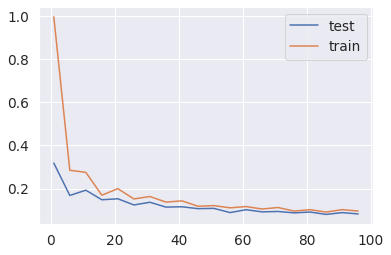

In [ ]:
plt.plot( range(1,100,5) , history_test  , label = 'test')
plt.plot( range(1,100,5) , history_train  , label = 'train')
plt.legend()

[1, 6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81, 86, 91, 96]

In [ ]:
from sklearn.model_selection import GridSearchCV
parameters = {'n_neighbors':range(1,100,5)}
KNN = KNeighborsClassifier()
clf = GridSearchCV(KNN, parameters , cv = 5 , verbose=10 , scoring='f1')
clf.fit(training_points, training_values)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5; 1/20] START n_neighbors=1..............................................
[CV 1/5; 1/20] END ...............n_neighbors=1;, score=0.308 total time=   1.0s
[CV 2/5; 1/20] START n_neighbors=1..............................................
[CV 2/5; 1/20] END ...............n_neighbors=1;, score=0.307 total time=   1.0s
[CV 3/5; 1/20] START n_neighbors=1..............................................
[CV 3/5; 1/20] END ...............n_neighbors=1;, score=0.304 total time=   0.9s
[CV 4/5; 1/20] START n_neighbors=1..............................................
[CV 4/5; 1/20] END ...............n_neighbors=1;, score=0.272 total time=   0.9s
[CV 5/5; 1/20] START n_neighbors=1..............................................
[CV 5/5; 1/20] END ...............n_neighbors=1;, score=0.284 total time=   1.1s
[CV 1/5; 2/20] START n_neighbors=6..............................................
[CV 1/5; 2/20] END ...............n_neighbors=6

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 100, 5)}, scoring='f1',
             verbose=10)

In [ ]:
clf.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_n_neighbors', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [ ]:
f1_score(test_values, clf.predict(test_points))

0.31843575418994413

In [ ]:
 clf.predict(test_points)

array([1, 0, 1, ..., 0, 0, 1])

In [ ]:
history = []
for k in range(30):
  model_knn = KNeighborsClassifier(n_neighbors= k+1 )
  model_knn.fit(training_points, training_values)
  predictions_knn= model_knn.predict(test_points)
  history.append(f1_score(test_values, predictions_knn))
  #print('KNN f1_score:', f1_score(test_values, predictions_knn))
  print(k)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


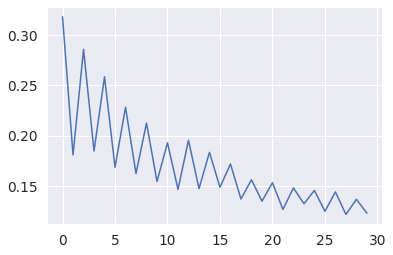

In [ ]:
plt.plot(history)